In [1]:
# Домашнее задание 4: Полный цикл построения модели линейной регрессии

## Описание датасета

#Используется датасет **California Housing**, встроенный в `sklearn.datasets`.  
#Он содержит информацию о домах в Калифорнии по данным переписи 1990 года.  
#Целевая переменная **медианная стоимость дома** (в сотнях тысяч долларов).  
#Количество наблюдений: 20640, признаков: 8 (включая MedInc, HouseAge, AveRooms и др.).

In [2]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Настройка визуализации
sns.set_style("whitegrid")
%matplotlib inline

print("Библиотеки загружены, SSL проверка отключена для загрузки датасета")

Библиотеки загружены, SSL проверка отключена для загрузки датасета


In [3]:
try:
    print("Попытка загрузить датасет через fetch_california_housing...")
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    print("Датасет успешно загружен!")
    
except Exception as e:
    print(f"Ошибка загрузки: {e}")
    print("\nПробуем альтернативный способ загрузки...")
    
    try:
        url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
        df = pd.read_csv(url)
        
        df.rename(columns={
            'longitude': 'Longitude',
            'latitude': 'Latitude',
            'housing_median_age': 'HouseAge',
            'total_rooms': 'AveRooms',
            'total_bedrooms': 'AveBedrms',
            'population': 'Population',
            'households': 'Households',
            'median_income': 'MedInc',
            'median_house_value': 'MedHouseVal'
        }, inplace=True)
        
        df['AveRooms'] = df['AveRooms'] / df['Households']
        df['AveBedrms'] = df['AveBedrms'] / df['Households']
        
        print("Датасет загружен с GitHub!")
        
    except Exception as e2:
        print(f"Ошибка загрузки с GitHub: {e2}")
        print("\nТРЕТИЙ СПОСОБ: создаем небольшой тестовый датасет для демонстрации")
        
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'MedInc': np.random.exponential(3, n_samples),
            'HouseAge': np.random.randint(1, 52, n_samples),
            'AveRooms': np.random.exponential(5, n_samples),
            'AveBedrms': np.random.exponential(1, n_samples),
            'Population': np.random.randint(100, 5000, n_samples),
            'AveOccup': np.random.exponential(3, n_samples),
            'Latitude': np.random.uniform(32, 42, n_samples),
            'Longitude': np.random.uniform(-124, -114, n_samples),
            'MedHouseVal': np.random.exponential(2, n_samples) * 2
        })
        print("Создан демонстрационный датасет (1000 записей)")

print("\n" + "="*50)
print("ПЕРВЫЕ 5 СТРОК:")
print("="*50)
display(df.head())

print("\n" + "="*50)
print("ИНФОРМАЦИЯ О ДАННЫХ:")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("ПРОВЕРКА ПРОПУСКОВ:")
print("="*50)
print(df.isnull().sum())

if df['AveBedrms'].isnull().sum() > 0:
    print("\nОбнаружены пропуски в AveBedrms, заполняем медианой...")
    df['AveBedrms'].fillna(df['AveBedrms'].median(), inplace=True)

Попытка загрузить датасет через fetch_california_housing...
Датасет успешно загружен!

ПЕРВЫЕ 5 СТРОК:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



ИНФОРМАЦИЯ О ДАННЫХ:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

ОПИСАТЕЛЬНАЯ СТАТИСТИКА:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



ПРОВЕРКА ПРОПУСКОВ:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


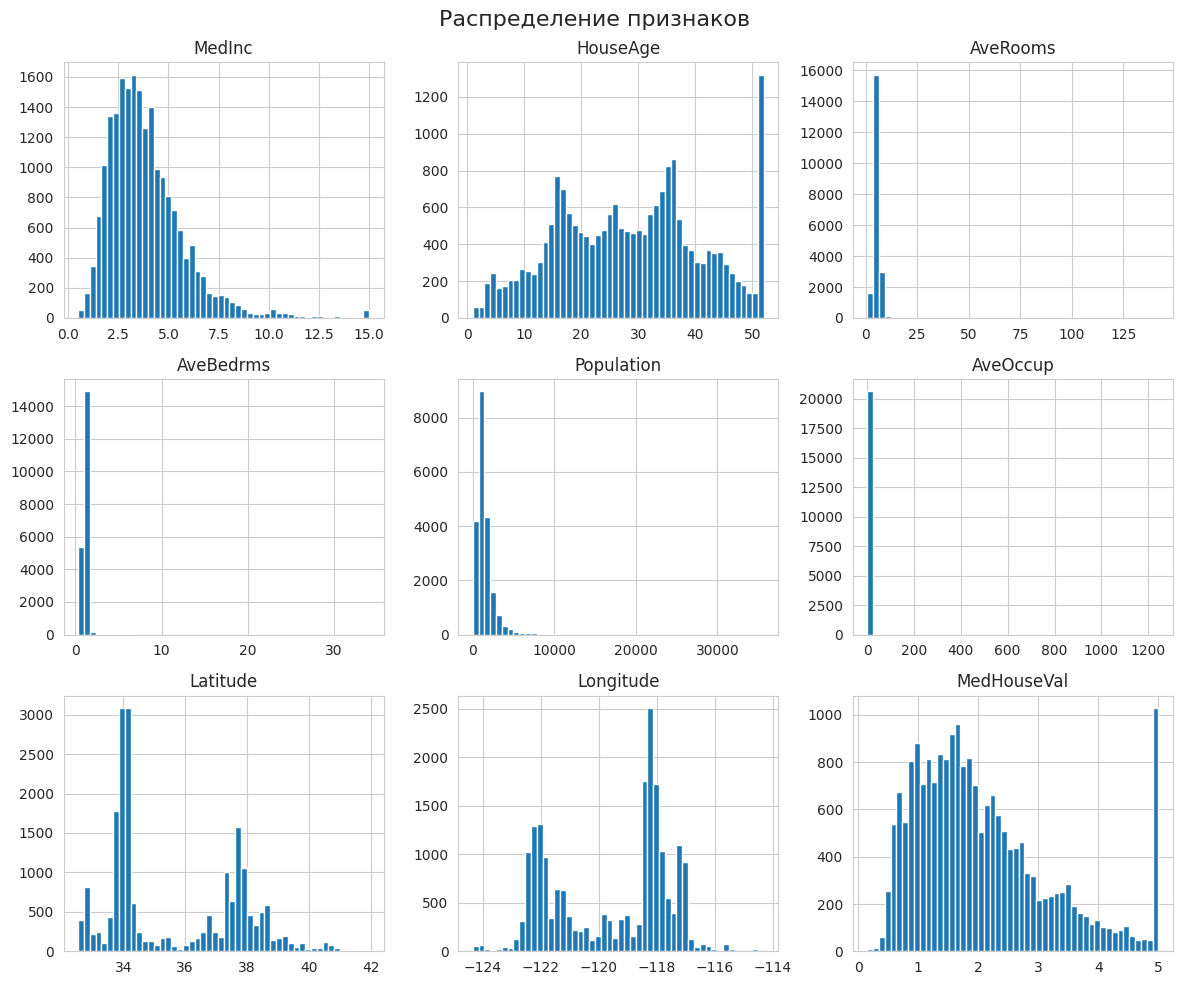

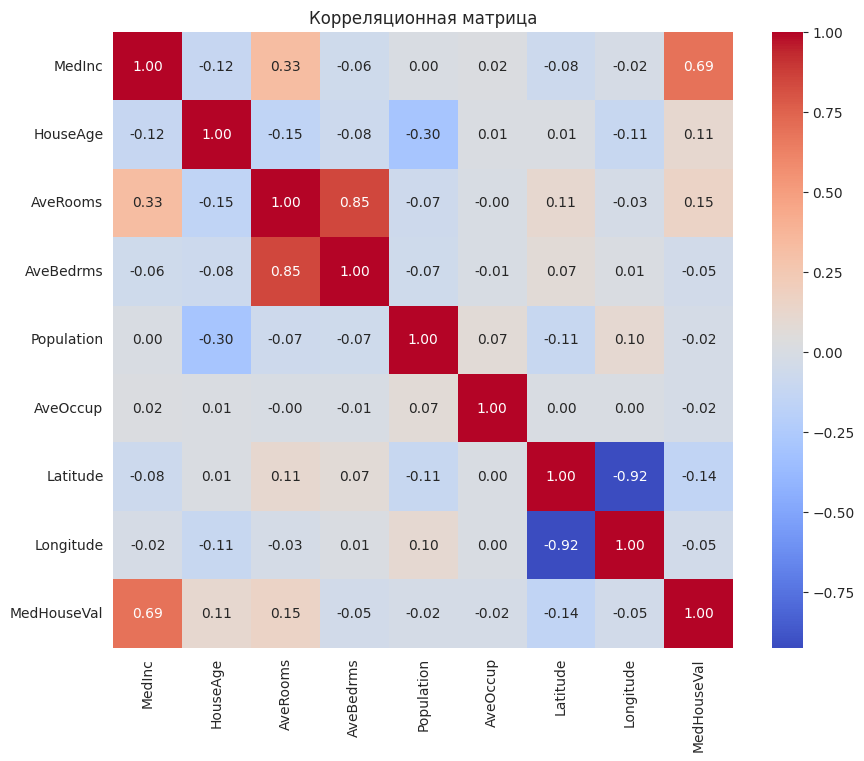

In [4]:
# Гистограммы признаков
df.hist(figsize=(12, 10), bins=50)
plt.suptitle("Распределение признаков", size=16)
plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

In [5]:
# Удаление выбросов по целевой переменной (например, > 5 сотен тысяч $)
Q1 = df['MedHouseVal'].quantile(0.25)
Q3 = df['MedHouseVal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['MedHouseVal'] >= lower_bound) & (df['MedHouseVal'] <= upper_bound)]
print(f"Удалено {len(df) - len(df_clean)} выбросов")

# Добавление полиномиальных признаков (степень 2 для MedInc и AveRooms)
poly = PolynomialFeatures(degree=2, include_bias=False)
interaction_features = poly.fit_transform(df_clean[['MedInc', 'AveRooms']])
feature_names = poly.get_feature_names_out(['MedInc', 'AveRooms'])
interaction_df = pd.DataFrame(interaction_features, columns=feature_names, index=df_clean.index)

# Объединение
df_augmented = pd.concat([df_clean, interaction_df], axis=1)
df_augmented.drop(columns=['MedInc', 'AveRooms'], inplace=True)  # оригинальные заменяем расширенными

print("Новые признаки:", list(interaction_df.columns))
print("Размер после инжиниринга:", df_augmented.shape)

Удалено 1071 выбросов
Новые признаки: ['MedInc', 'AveRooms', 'MedInc^2', 'MedInc AveRooms', 'AveRooms^2']
Размер после инжиниринга: (19569, 10)


In [6]:
X = df_augmented.drop('MedHouseVal', axis=1)
y = df_augmented['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование (обучаем на train, преобразуем train и test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train_scaled.shape}")
print(f"Размер тестовой выборки: {X_test_scaled.shape}")

Размер обучающей выборки: (15655, 9)
Размер тестовой выборки: (3914, 9)


In [7]:
# Линейная регрессия
lr = LinearRegression()
%time lr.fit(X_train_scaled, y_train)

# Ridge с подбором alpha
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
%time ridge_cv.fit(X_train_scaled, y_train)
print("Лучшая alpha для Ridge:", ridge_cv.best_params_)

# Lasso с подбором alpha
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
%time lasso_cv.fit(X_train_scaled, y_train)
print("Лучшая alpha для Lasso:", lasso_cv.best_params_)

CPU times: user 31.8 ms, sys: 25.3 ms, total: 57.1 ms
Wall time: 61.9 ms
CPU times: user 500 ms, sys: 40.9 ms, total: 541 ms
Wall time: 68.3 ms
Лучшая alpha для Ridge: {'alpha': 100}
CPU times: user 420 ms, sys: 26.5 ms, total: 446 ms
Wall time: 56.1 ms
Лучшая alpha для Lasso: {'alpha': 0.01}


In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    print(f"=== {name} ===")
    print(f"RMSE train: {rmse_train:.4f}")
    print(f"RMSE test : {rmse_test:.4f}")
    print(f"MAE test  : {mae_test:.4f}")
    print(f"R^2 test  : {r2_test:.4f}")
    print(f"Разница RMSE: {rmse_test - rmse_train:.4f}\n")
    return rmse_train, rmse_test, r2_test

# Линейная регрессия
lr_rmse_tr, lr_rmse_te, lr_r2 = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, "LinearRegression")

# Ridge
ridge_best = ridge_cv.best_estimator_
_, ridge_rmse_te, ridge_r2 = evaluate_model(ridge_best, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge")

# Lasso
lasso_best = lasso_cv.best_estimator_
_, lasso_rmse_te, lasso_r2 = evaluate_model(lasso_best, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso")

=== LinearRegression ===
RMSE train: 0.6477
RMSE test : 0.6288
MAE test  : 0.4752
R^2 test  : 0.5724
Разница RMSE: -0.0188

=== Ridge ===
RMSE train: 0.6484
RMSE test : 0.6303
MAE test  : 0.4767
R^2 test  : 0.5704
Разница RMSE: -0.0181

=== Lasso ===
RMSE train: 0.6518
RMSE test : 0.6338
MAE test  : 0.4803
R^2 test  : 0.5656
Разница RMSE: -0.0180



In [9]:
results = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge", "Lasso"],
    "Test RMSE": [lr_rmse_te, ridge_rmse_te, lasso_rmse_te],
    "Test R²": [lr_r2, ridge_r2, lasso_r2]
})
print("Сравнение моделей на тестовой выборке:")
display(results.sort_values("Test RMSE"))

Сравнение моделей на тестовой выборке:


,Model,Test RMSE,Test R²
0,LinearRegression,0.628830,0.572429
1,Ridge,0.630285,0.570448
2,Lasso,0.633833,0.565597
